In [126]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ---- Konfigurasi ----
TOP_K_LIST = [3, 5, 10]     # kandidat K yang diuji
K_CANON    = 5              # K terpilih untuk tabel final (lihat justifikasi Spearman di bawah)
ALPHA      = 0.6            # bobot Rule-Based dalam Hybrid Score (Content = 1-ALPHA)
TOP_N      = 20             # jumlah baris yang ditampilkan/di-plot

# NOTE: ganti dua baris ini kalau Rule_Score kamu sudah dihitung di cell lain
W_RATING   = 0.5            # bobot Rating dalam Rule Score
W_FACILITY = 0.5            # bobot Jumlah Fasilitas dalam Rule Score

def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx == mn else (arr - mn) / (mx - mn)

In [ ]:
INPUT_CSV = 'Database Inventarisasi DTW_FIKSSS.csv'  # GANTI sesuai path file kamu

df_inventory = pd.read_csv(INPUT_CSV)
df_inventory.columns = df_inventory.columns.str.strip()

if 'Destinasi' not in df_inventory.columns:
    raise KeyError("Kolom 'Destinasi' tidak ditemukan.")

print(f"Data dimuat: {len(df_inventory)} baris, {len(df_inventory.columns)} kolom")
df_inventory.head()

Data dimuat: 315 baris, 33 kolom


,Destinasi,2. Alamat,3. Kalurahan/Kelurahan,4. Kapanewon/Kemantren,4.a. Kabupaten /kota,5. Status Lahan,6. Koordinat,7. Kontak Pengelola 1,7. Kontak Pengelola 2,8. Situs/website,...,Parkir Mobil,Jam Buka Weekday,Jam Buka Weekend dan Libur Nasional,Toilet,Tempat Sampah,CCTV,Area Parkir,Area Makanan/kafetaria/Restoran,Ruang Ibadah,Area Istirahat Pengunjung
0,Embung Nglanggeran,"Nglanggeran Wetan, Nglanggeran, Kec. Patuk",Nglanggeran,Patuk,Gunungkidul,"Tanah Kasultanan, Sebagian pada lahan parkir dan fasilitas lain SHM","-7.8469698382471025, 110.5467623332984",087838747151,-,Desa Wisata Nglanggeran.id,...,"Rp5,000",08.00-17.00,00.00-23.59,Ada,Ada,Ada,Ada,Ada,Ada,Ada
1,Grand Puri Waterpark,"Gabusan, Jl. Parangtritis No.KM. 9, Balong",Timbulharjo,Sewon,Bantul,-,"-7.877607423156831, 110.35291948300323",-,-,-,...,"Rp5,000",09.00-17.00,08.00-17.00,Tidak Ada,Tidak Ada,Tidak Ada,Tidak Ada,Ada,Tidak Ada,Tidak Ada
2,Embung Jlamprong,Mojo,Ngeposari,Semanu,Gunungkidul,Tanah Kas Desa,"-8.01010118132162, 110.67675400608971",082135410822,-,-,...,Rp0,00.00-23.59,00.00-23.59,Ada,Ada,Tidak Ada,Ada,Ada,Tidak Ada,Ada
3,Taman Jamu Naturindo,Clereng,Sendangsari,Pengasih,Kulon Progo,NaN,NaN,NaN,NaN,NaN,...,"Rp5,000",07.30-15.30,07.30-12.30,Ada,Ada,Tidak Ada,Ada,Ada,Ada,Tidak Ada
4,Taman Tebing Breksi,"Jl. Desa Lengkong, RT.02/RW.17, Gn. Sari",Sambirejo,Prambanan,Sleman,Tanah Kasultanan,"-7.78340, 110.50420",081353393327 (Dwi),081353393327,www tebingbreksi.com,...,"Rp5,000",06.00-20.00,06.00-20.00,Ada,Ada,Ada,Ada,Ada,Ada,Ada


In [ ]:
facility_cols = [
    'Toilet', 'Tempat Sampah', 'CCTV', 'Area Parkir',
    'Area Makanan/kafetaria/Restoran', 'Ruang Ibadah', 'Area Istirahat Pengunjung'
]
presence_values = {'ada', 'yes', 'y', '1', 'true', 'ya', 'iya', 't', 'v', 'available'}

def is_present(val):
    if pd.isna(val):
        return False
    s = str(val).strip().lower()
    if s in presence_values or 'ada' in s or 'yes' in s or 'available' in s:
        return True
    try:
        return float(s) > 0
    except ValueError:
        return False

def slug(s):
    return str(s).strip().lower().replace(' ', '_').replace('/', '_')

feature_rows = []
for _, row in df_inventory.iterrows():
    jenis = row.get('Jenis Wisata', '') or 'jenis_unknown'
    tokens = [f"wisata:{slug(jenis)}"]
    facility_count = 0
    for col in facility_cols:
        if col in row.index and is_present(row[col]):
            tokens.append(f"fasilitas:{slug(col)}")
            facility_count += 1
    if 'Kabupaten' in row.index and pd.notna(row['Kabupaten']):
        tokens.append(f"kab:{slug(row['Kabupaten'])}")
    if 'Rating' in row.index and pd.notna(row['Rating']):
        r = float(row['Rating'])
        tokens.append('rating:very_high' if r >= 4.5 else
                       'rating:high' if r >= 4.0 else
                       'rating:medium' if r >= 3.0 else 'rating:low')
    content_str = ' '.join(tokens) if tokens else 'no_features'
    feature_rows.append({
        'Destinasi': row.get('Destinasi', ''),
        'Jenis Wisata': row.get('Jenis Wisata', ''),
        'Jumlah Fasilitas': facility_count,
        'Fitur Konten': content_str
    })

df_features = pd.DataFrame(feature_rows)
print(f"Ekstraksi fitur selesai untuk {len(df_features)} destinasi")
df_features.head()

Ekstraksi fitur selesai untuk 315 destinasi


,Destinasi,Jenis Wisata,Jumlah Fasilitas,Fitur Konten
0,Embung Nglanggeran,Taman Rekreasi,7,wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung
1,Grand Puri Waterpark,Taman Rekreasi,7,wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung
2,Embung Jlamprong,Taman Rekreasi,7,wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung
3,Taman Jamu Naturindo,Taman Rekreasi,7,wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung
4,Taman Tebing Breksi,Taman Rekreasi,7,wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung


In [ ]:
MAX_FEATURES_FEATURETOKENS = 500
MAX_FEATURES_DESC = 500

vectorizer_features = TfidfVectorizer(analyzer='word', token_pattern=r'[^ ]+',
                                       max_features=MAX_FEATURES_FEATURETOKENS, lowercase=True)
X_feat = vectorizer_features.fit_transform(df_features['Fitur Konten'])

if 'Deskripsi' in df_inventory.columns:
    vectorizer_desc = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                                       max_features=MAX_FEATURES_DESC, lowercase=True)
    X_desc = vectorizer_desc.fit_transform(df_inventory['Deskripsi'].fillna('').astype(str))
    tfidf_matrix = hstack([X_feat, X_desc], format='csr')
else:
    tfidf_matrix = X_feat

print(f"TF-IDF shape: {tfidf_matrix.shape}")

TF-IDF shape: (315, 11)


In [ ]:
cosine_sim_matrix = cosine_similarity(tfidf_matrix)
n = len(df_inventory)
print(f"Cosine similarity matrix: {cosine_sim_matrix.shape}")

Cosine similarity matrix: (315, 315)


In [ ]:
similarities = cosine_sim_matrix[np.triu_indices_from(cosine_sim_matrix, k=1)]
mean_sim = similarities.mean()
print(f"Rata-rata cosine similarity antar destinasi: {mean_sim:.4f}")
print(pd.Series(similarities).describe())

if mean_sim > 0.8:
    print("⚠️ Similarity sangat tinggi (>0.8) — pertimbangkan menambah fitur (deskripsi/lokasi/harga).")
elif mean_sim > 0.6:
    print("⚠️ Similarity medium (0.6-0.8).")
else:
    print("✓ Similarity rendah (<0.6) — Content-Based bekerja baik.")

Rata-rata cosine similarity antar destinasi: 0.7338
count    49455.000000
mean         0.733786
std          0.213154
min          0.390436
25%          0.595467
50%          0.627138
75%          1.000000
max          1.000000
dtype: float64
⚠️ Similarity medium (0.6-0.8).


  Persentil 10: 0.5134
  Persentil 25: 0.5955
  Persentil 50: 0.6271
  Persentil 75: 1.0000
  Persentil 90: 1.0000
  Persentil 95: 1.0000
  Persentil 99: 1.0000


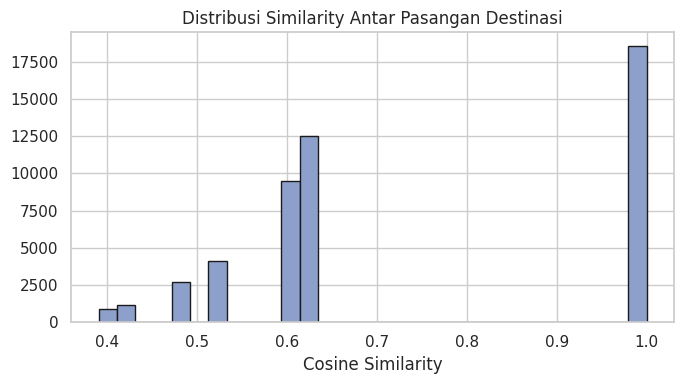

In [ ]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"  Persentil {p}: {np.percentile(similarities, p):.4f}")

plt.figure(figsize=(7, 4))
plt.hist(similarities, bins=30, color='#8da0cb', edgecolor='k')
plt.xlabel('Cosine Similarity')
plt.title('Distribusi Similarity Antar Pasangan Destinasi')
plt.tight_layout()
plt.show()

In [ ]:
TOP_K_SIMILAR = 10
dest_names = df_inventory['Destinasi'].values
top_similar_list = []
for i in range(n):
    sims = cosine_sim_matrix[i].copy()
    sims[i] = -1
    idx = np.argsort(sims)[::-1][:TOP_K_SIMILAR]
    top_similar_list.append({
        'Destinasi': dest_names[i],
        'Distinctiveness': 1 - np.delete(cosine_sim_matrix[i], i).mean(),
        f'Top{TOP_K_SIMILAR}_Similar': '; '.join(dest_names[idx])
    })

df_dest_scores = pd.DataFrame(top_similar_list)
df_dest_scores.sort_values('Distinctiveness', ascending=False).head(10)

,Destinasi,Distinctiveness,Top10_Similar
277,Kraton,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Gua Maria Sendangsono ; Affandi Museum; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
273,Museum Serat Holistik Kehidupan Susilawati Susmoni,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Gua Maria Sendangsono ; Affandi Museum; Kraton; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
147,Museum Kereta Kraton/ Museum Wahanarata,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Gua Maria Sendangsono ; Museum Gerabah Kasongan
77,Museum Andi Bayou,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Sendangsono ; Gua Maria Tritis; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
292,Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa,0.529016,Museum Wayang Kekayon; Gua Maria Sendangsono ; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
290,Museum Wayang Kekayon,0.529016,Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Sendangsono ; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
152,Sendra Tari Ramayana Ballet (Outdoor),0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Gua Maria Sendangsono ; Museum Gerabah Kasongan
158,Museum Wayang Beber Sekartaji,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Gua Maria Sendangsono ; Museum Gerabah Kasongan
258,Affandi Museum,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Gua Maria Sendangsono ; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Museum Wayang Beber Sekartaji ; Sendra Tari Ramayana Ballet (Outdoor)
246,Taman Sari Kraton Yogyakarta,0.529016,Museum Wayang Kekayon; Ndalem Pojokusuman / Pamulangan Beksa Sasminta Mardawa; Gua Maria Tritis; Museum Andi Bayou ; Affandi Museum; Kraton; Museum Serat Holistik Kehidupan Susilawati Susmoni; Wisata Wayang Wukirsari; Gua Maria Sendangsono ; Sendra Tari Ramayana Ballet (Outdoor)


In [ ]:
TOP_K_LIST = [3, 5, 10]

def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    mn, mx = arr.min(), arr.max()
    return np.zeros_like(arr) if mx == mn else (arr - mn) / (mx - mn)

def content_score_topk(k):
    scores = np.zeros(n)
    for i in range(n):
        sims = np.delete(cosine_sim_matrix[i], i)
        scores[i] = sims[np.argsort(sims)[-k:]].mean()
    return normalize(scores)

content_scores = {k: content_score_topk(k) for k in TOP_K_LIST}
print("Content Score dihitung untuk K =", TOP_K_LIST)

Content Score dihitung untuk K = [3, 5, 10]


In [ ]:
# Fallback Rule Score (Rating + Jumlah Fasilitas) — ganti jika Rule_Score sudah ada
W_RATING = 0.5
W_FACILITY = 0.5

rating = pd.to_numeric(df_inventory['Rating Maps'], errors='coerce').fillna(0).values
facility = df_features['Jumlah Fasilitas'].values
rule_score = W_RATING * normalize(rating) + W_FACILITY * normalize(facility)

In [ ]:
ALPHA = 0.6  # bobot Rule-Based; Content = 1 - ALPHA

df_all = pd.DataFrame({'Destinasi': df_inventory['Destinasi'].values, 'Rule_Score': rule_score})
df_all['Rank_Rule'] = df_all['Rule_Score'].rank(ascending=False, method='min').astype(int)

for k in TOP_K_LIST:
    df_all[f'Content_Score_k{k}'] = content_scores[k]
    df_all[f'Hybrid_Score_k{k}'] = ALPHA * rule_score + (1 - ALPHA) * content_scores[k]
    df_all[f'Rank_Hybrid_k{k}'] = df_all[f'Hybrid_Score_k{k}'].rank(ascending=False, method='min').astype(int)

In [ ]:
topk_comparison = pd.DataFrame({
    'K': TOP_K_LIST,
    'Mean_Content_Score': [content_scores[k].mean() for k in TOP_K_LIST],
    'Std_Content_Score': [content_scores[k].std() for k in TOP_K_LIST],
    'Mean_Hybrid_Score': [df_all[f'Hybrid_Score_k{k}'].mean() for k in TOP_K_LIST],
    'Std_Hybrid_Score': [df_all[f'Hybrid_Score_k{k}'].std() for k in TOP_K_LIST],
})
topk_comparison

,K,Mean_Content_Score,Std_Content_Score,Mean_Hybrid_Score,Std_Hybrid_Score
0,3,0.177778,0.382326,0.256532,0.15252
1,5,0.177778,0.382326,0.256532,0.15252
2,10,0.177778,0.382326,0.256532,0.15252


In [ ]:
print("Korelasi Spearman antar pilihan K (Hybrid Ranking):")
for i in range(len(TOP_K_LIST)):
    for j in range(i + 1, len(TOP_K_LIST)):
        k1, k2 = TOP_K_LIST[i], TOP_K_LIST[j]
        rho, p = spearmanr(df_all[f'Rank_Hybrid_k{k1}'], df_all[f'Rank_Hybrid_k{k2}'])
        print(f"  K={k1} vs K={k2}: rho={rho:.4f} (p={p:.3g})")

Korelasi Spearman antar pilihan K (Hybrid Ranking):
  K=3 vs K=5: rho=1.0000 (p=0)
  K=3 vs K=10: rho=1.0000 (p=0)
  K=5 vs K=10: rho=1.0000 (p=0)


In [ ]:
K_CANON = 5  # GANTI sesuai kesimpulan dari hasil Top-K Comparison & Spearman di atas
print(f"K yang dipilih: {K_CANON}")

K yang dipilih: 5


In [ ]:
df_final = df_all[['Destinasi', 'Rule_Score', f'Content_Score_k{K_CANON}', f'Hybrid_Score_k{K_CANON}',
                    'Rank_Rule', f'Rank_Hybrid_k{K_CANON}']].copy()
df_final.columns = ['Destinasi', 'Rule_Score', 'Content_Score', 'Hybrid_Score', 'Rank_Rule', 'Rank_Hybrid']
df_final['Delta_Rank'] = df_final['Rank_Rule'] - df_final['Rank_Hybrid']
df_final['Movement'] = np.select(
    [df_final['Delta_Rank'] > 0, df_final['Delta_Rank'] < 0],
    ['Naik', 'Turun'], default='Tetap'
)
df_final['Rule_Contribution'] = ALPHA * df_final['Rule_Score']
df_final['Content_Contribution'] = (1 - ALPHA) * df_final['Content_Score']

# Diurutkan berdasarkan Hybrid Score — INI skor akhir yang dipakai sistem rekomendasi
df_final = df_final.sort_values('Hybrid_Score', ascending=False).reset_index(drop=True)
df_final['Rank'] = np.arange(1, len(df_final) + 1)
df_final['Recommendation_Score'] = (df_final['Hybrid_Score'] * 100).round(2)
df_final['Recommendation_Label'] = np.where(
    df_final['Hybrid_Score'] >= 0.80, 'Sangat Direkomendasikan',
    np.where(df_final['Hybrid_Score'] >= 0.60, 'Direkomendasikan', 'Alternatif')
)

df_final.head(20)

,Destinasi,Rule_Score,Content_Score,Hybrid_Score,Rank_Rule,Rank_Hybrid,Delta_Rank,Movement,Rule_Contribution,Content_Contribution,Rank,Recommendation_Score,Recommendation_Label
0,Aloe Land,0.423077,1.0,0.653846,9,1,8,Naik,0.253846,0.4,1,65.38,Direkomendasikan
1,Wisata Bojong Asri,0.423077,1.0,0.653846,9,1,8,Naik,0.253846,0.4,2,65.38,Direkomendasikan
2,Pictniq,0.384615,1.0,0.630769,25,3,22,Naik,0.230769,0.4,3,63.08,Direkomendasikan
3,Ekowisata Nologaten,0.384615,1.0,0.630769,25,3,22,Naik,0.230769,0.4,4,63.08,Direkomendasikan
4,Chocolate Monggo Museum New Factory Store Kedai & Gelato,0.384615,1.0,0.630769,25,3,22,Naik,0.230769,0.4,5,63.08,Direkomendasikan
5,Kaliurang Park Botanical Garden,0.384615,1.0,0.630769,25,3,22,Naik,0.230769,0.4,6,63.08,Direkomendasikan
6,Ledok Sambi Ecopark,0.384615,1.0,0.630769,25,3,22,Naik,0.230769,0.4,7,63.08,Direkomendasikan
7,Waterbom Jogja,0.346154,1.0,0.607692,72,8,64,Naik,0.207692,0.4,8,60.77,Direkomendasikan
8,Gembira Loka Zoo,0.346154,1.0,0.607692,72,8,64,Naik,0.207692,0.4,9,60.77,Direkomendasikan
9,Wana Delima Orchard,0.346154,1.0,0.607692,72,8,64,Naik,0.207692,0.4,10,60.77,Direkomendasikan


In [ ]:
top10_rule = set(df_final.sort_values('Rule_Score', ascending=False).head(10)['Destinasi'])
top10_content = set(df_final.sort_values('Content_Score', ascending=False).head(10)['Destinasi'])
top10_hybrid = set(df_final.head(10)['Destinasi'])

ablation = pd.DataFrame({
    'Metode': ['Rule-Only', 'Content-Only', 'Hybrid'],
    'Top-10 Destinasi': [
        ', '.join(sorted(top10_rule)),
        ', '.join(sorted(top10_content)),
        ', '.join(sorted(top10_hybrid)),
    ],
    'Overlap dgn Hybrid (dari 10)': [
        len(top10_rule & top10_hybrid),
        len(top10_content & top10_hybrid),
        10,
    ],
})
ablation

,Metode,Top-10 Destinasi,Overlap dgn Hybrid (dari 10)
0,Rule-Only,"Candi ijo, Diorama Arsip Jogja , Gua Maria Sendangsono , Gua Maria Tritis, Museum Andi Bayou , Museum Batik, Museum Laboratorium Sejarah UPY, Museum Muhammadiyah , Museum Paleoantropologi, Museum Serat Holistik Kehidupan Susilawati Susmoni",0
1,Content-Only,"Agro wisata Turi, Balong Waterpark, Bendungan Kamijoro, Embung Kleco, Etalase Taman Batu Geopark Gunung Sewu, Kolam Renang Tirto Tamansari, Omah Salak, Telaga Kemuning, Teras Kaca, Waterbyur",0
2,Hybrid,"Aloe Land, Chocolate Monggo Museum New Factory Store Kedai & Gelato, Ekowisata Nologaten, Gembira Loka Zoo, Kaliurang Park Botanical Garden , Ledok Sambi Ecopark, Pictniq, Wana Delima Orchard, Waterbom Jogja, Wisata Bojong Asri",10


In [ ]:
top5 = df_final.head(5)
top5[['Rank', 'Destinasi', 'Rule_Score', 'Content_Score', 'Hybrid_Score', 'Movement']]

,Rank,Destinasi,Rule_Score,Content_Score,Hybrid_Score,Movement
0,1,Aloe Land,0.423077,1.0,0.653846,Naik
1,2,Wisata Bojong Asri,0.423077,1.0,0.653846,Naik
2,3,Pictniq,0.384615,1.0,0.630769,Naik
3,4,Ekowisata Nologaten,0.384615,1.0,0.630769,Naik
4,5,Chocolate Monggo Museum New Factory Store Kedai & Gelato,0.384615,1.0,0.630769,Naik


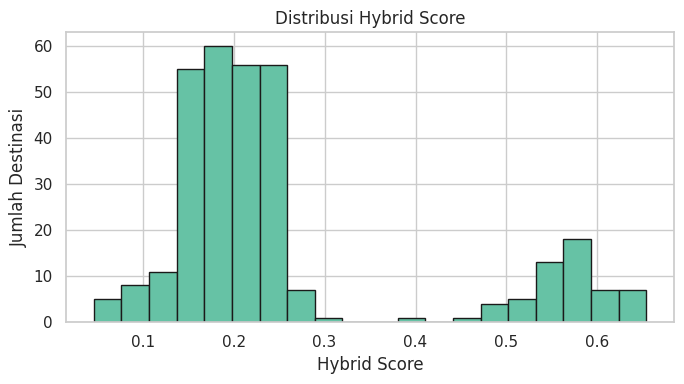

In [ ]:
# Distribusi Hybrid Score
plt.figure(figsize=(7, 4))
plt.hist(df_final['Hybrid_Score'], bins=20, color='#66c2a5', edgecolor='k')
plt.xlabel('Hybrid Score')
plt.ylabel('Jumlah Destinasi')
plt.title('Distribusi Hybrid Score')
plt.tight_layout()
plt.savefig('HYBRID_SCORE_DISTRIBUTION.png', dpi=150, bbox_inches='tight')
plt.show()

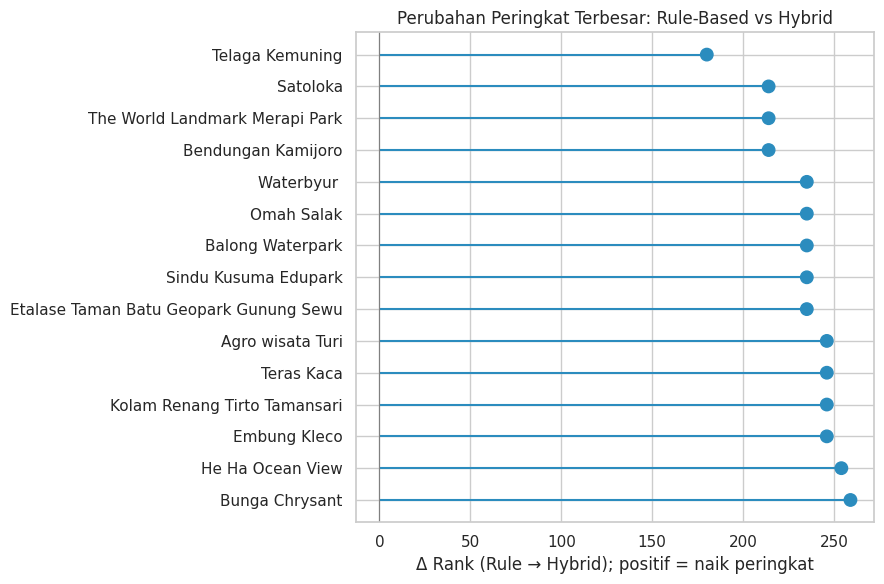

In [ ]:
# Perubahan Ranking (lollipop chart, 15 pergeseran terbesar)
plot_df = df_final.reindex(df_final['Delta_Rank'].abs().sort_values(ascending=False).index).head(15)
colors = np.where(plot_df['Delta_Rank'] >= 0, '#2b8cbe', '#e34a33')

plt.figure(figsize=(9, 6))
plt.hlines(y=plot_df['Destinasi'], xmin=0, xmax=plot_df['Delta_Rank'], color=colors)
plt.scatter(plot_df['Delta_Rank'], plot_df['Destinasi'], color=colors, s=80, zorder=3)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Δ Rank (Rule → Hybrid); positif = naik peringkat')
plt.title('Perubahan Peringkat Terbesar: Rule-Based vs Hybrid')
plt.tight_layout()
plt.savefig('RANKING_CHANGE.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_final.to_csv('FINAL_HYBRID_SCORES.csv', index=False)
df_final.to_json('FINAL_HYBRID_SCORES.json', orient='records', indent=2, force_ascii=False)
topk_comparison.to_csv('TOPK_COMPARISON.csv', index=False)
ablation.to_csv('ABLATION_STUDY.csv', index=False)

print("✓ Export selesai:")
print("  - FINAL_HYBRID_SCORES.csv / .json  (dipakai website)")
print("  - TOPK_COMPARISON.csv               (lampiran Bab IV)")
print("  - ABLATION_STUDY.csv                (lampiran Bab IV)")

✓ Export selesai:
  - FINAL_HYBRID_SCORES.csv / .json  (dipakai website)
  - TOPK_COMPARISON.csv               (lampiran Bab IV)
  - ABLATION_STUDY.csv                (lampiran Bab IV)


UNTUK CEK SIMILARITY (kenapa 1.000)

In [ ]:
pd.set_option("display.max_colwidth", None)

print(
    df_features[
        ["Destinasi","Fitur Konten"]
    ].head(20)
)

                      Destinasi  \
0            Embung Nglanggeran   
1          Grand Puri Waterpark   
2              Embung Jlamprong   
3          Taman Jamu Naturindo   
4           Taman Tebing Breksi   
5           Ekowisata Nologaten   
6      Jogja Mini Zoo Exotarium   
7          Embung Batara Sriten   
8                 Lembah Sorory   
9             Bejiharjo Edupark   
10            The Manglung View   
11           Bendungan Kamijoro   
12           Wisata Bojong Asri   
13  Gamplong Studio Alam Sleman   
14          Ledok Sambi Ecopark   
15               De Mangol View   
16                 Waduk Sermo    
17     Suraloka Interactive Zoo   
18               Obelix Village   
19       Galaxy Waterpark Jogja   

                                                                                                                                                                                                Fitur Konten  
0   wisata:taman_rekreasi fasilitas:toilet fasilitas:temp

In [ ]:
for i in range(5):
    sim = cosine_sim_matrix[i].copy()

    sim[i] = -1

    idx = np.argsort(sim)[::-1][:5]

    print(df_inventory.iloc[i]["Destinasi"])

    print(sim[idx])

    print(df_inventory.iloc[idx]["Destinasi"].tolist())

    print("-"*70)

Embung Nglanggeran
[1. 1. 1. 1. 1.]
['Grand Puri Waterpark', 'Embung Jlamprong', 'Taman Jamu Naturindo', 'Stone Valley', 'Embung Tonogoro ']
----------------------------------------------------------------------
Grand Puri Waterpark
[1. 1. 1. 1. 1.]
['Embung Nglanggeran', 'Embung Jlamprong', 'Taman Jamu Naturindo', 'Stone Valley', 'Embung Tonogoro ']
----------------------------------------------------------------------
Embung Jlamprong
[1. 1. 1. 1. 1.]
['Embung Nglanggeran', 'Grand Puri Waterpark', 'Taman Jamu Naturindo', 'Stone Valley', 'Embung Tonogoro ']
----------------------------------------------------------------------
Taman Jamu Naturindo
[1. 1. 1. 1. 1.]
['Embung Nglanggeran', 'Grand Puri Waterpark', 'Embung Jlamprong', 'Stone Valley', 'Embung Tonogoro ']
----------------------------------------------------------------------
Taman Tebing Breksi
[1. 1. 1. 1. 1.]
['Embung Nglanggeran', 'Grand Puri Waterpark', 'Embung Jlamprong', 'Stone Valley', 'Embung Tonogoro ']
------------

In [ ]:
print("="*80)
print("JUMLAH KOMBINASI FITUR UNIK")
print("="*80)

print(df_features["Fitur Konten"].nunique())
print(len(df_features))

print("\n20 kombinasi fitur yang paling sering muncul:")
print(df_features["Fitur Konten"].value_counts().head(20))

JUMLAH KOMBINASI FITUR UNIK
4
315

20 kombinasi fitur yang paling sering muncul:
Fitur Konten
wisata:alam fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung              169
wisata:sejarah fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung            74
wisata:taman_rekreasi fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung     56
wisata:budaya fasilitas:toilet fasilitas:tempat_sampah fasilitas:cctv fasilitas:area_parkir fasilitas:area_makanan_kafetaria_restoran fasilitas:ruang_ibadah fasilitas:area_istirahat_pengunjung             16
Name: count, dtype: int64
